# The Random Walk Index — a quantitative teardown 🔬
### Flag-day Welch/HAC splits · a matched-count random-day placebo · cross-instrument pooling · the fair (block-shuffled, exposure-matched) trading control · cost sweeps · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Poulos' **Random Walk Index** compares realized price displacement to the expected displacement of a pure random walk of the same Average True Range — RWI-high(n) = (High_t − Low_{t−n}) / (ATR_n(t) × √n), reported as the max over n = 2..6 — and claims RWI-high > 1 flags a real, ride-able trend. The job here is to measure that honestly, on the real tape, against a fair control.

> ⚠️ **Data note.** SPY + QQQ/IWM/DIA/GLD daily total-return-adjusted OHLC (2005→2026), yfinance, cached. No survivorship anywhere in this study (index ETFs / a commodity tracker, no cross-sectional panel). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `98e6db1a1e26` / `70e1bc4a725e` / `7c02d693031f` / `f1faf16222de` / `a0f0673984c4`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from random_walk_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BASKET = data.load_basket()
    SPY_RAW = BASKET[data.HEADLINE]
    DF = st.day_frame(SPY_RAW)
else:
    BASKET = SPY_RAW = DF = None
print("real cache present:", HAVE_REAL, "| SPY tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'periods': (2, 3, 4, 5, 6), 'n_flag': 3067, 'n_rest': 2336, 'flag_freq': 56.8, 'flag_bps': 2.41, 'rest_bps': 8.07, 'gap_bps': -5.66, 'welch_t': -1.64, 'nw_t': -1.74, 'hit_up': 1691, 'hit_pct': 55.1, 'wilson': (53.4, 56.9), 'placebo_obs': 2.41, 'placebo_mean': 4.85, 'placebo_sd': 1.41, 'placebo_p': 0.9591, 'placebo_draws': 20000, 'per_ticker': {'SPY': (3067, 2.41, 8.07, -5.66, -1.64, -1.74, 55.1), 'QQQ': (3013, 4.98, 8.84, -3.86, -0.99, -1.06, 55.9), 'IWM': (2783, 1.06, 8.4, -7.34, -1.76, -1.82, 52.4), 'DIA': (2955, 3.84, 5.25, -1.41, -0.44, -0.47, 55.4), 'GLD': (2771, 5.04, 4.24, 0.8, 0.26, 0.27, 52.4)}, 'pooled_n': 27015, 'pooled_flag_bps': 3.47, 'pooled_rest_bps': 6.92, 'pooled_t': -2.16, 'gross_ret': 81.76, 'gross_sharpe': 0.301, 'net5_ret': 0.55, 'net5_sharpe': 0.06, 'net10_ret': -44.39, 'net10_sharpe': -0.181, 'bh_ret': 831.34, 'bh_sharpe': 0.644, 'exposure': 56.8, 'n_trades': 1184, 'ann_cost': 2.76, 'rc_mean_ret': 98.6, 'rc_sd_ret': 58.86, 'rc_mean_sharpe': 0.28, 'rc_sd_sharpe': 0.105, 'rc_beat_ret_pct': 90, 'rc_beat_sharpe_pct': 95, 'syn_null_mean': -0.03, 'syn_null_sd': 1.09, 'syn_null_fire': 1, 'syn_planted_t': 9.54, 'syn_planted_hit': 64.6, 'fp_spy': '98e6db1a1e26', 'fp_qqq': '70e1bc4a725e', 'fp_iwm': '7c02d693031f', 'fp_dia': 'f1faf16222de', 'fp_gld': 'a0f0673984c4'}


real cache present: True | SPY tape days: 5404


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | flag-day next-session return **+2.41 bps** vs +8.07 bps (SPY Welch *t* = -1.64); pooled 5-market Welch *t* = **-2.16** (wrong-signed, clears the bar); random-day placebo *p* = 0.9591 |
| **Tradability** | `MIRAGE` | timer +81.8% gross / +0.6% net(5bp) / -44.4% net(10bp) vs buy&hold +831.3%; random-entry control beats it in 90% of draws |
| **Beats a coin?** | `BUSTED` | exposure-matched random control mean +98.6% (sd 58.9) vs timer +0.6% |

> 💡 In plain words: the indicator measures a real, well-defined displacement statistic — it just isn't predictive, and pooled it's mildly predictive of the *wrong* thing.

## 1 · The claim, steelmanned

Let $D_{n,t} = \text{High}_t - \text{Low}_{t-n}$ be the realized *n*-session high-low displacement and $\overline{ATR}_n(t)$ the simple *n*-bar average True Range. Under a pure random walk with i.i.d. step size ~ $\overline{ATR}_n$, the expected net displacement over *n* steps scales like $\overline{ATR}_n \sqrt{n}$ (the standard Brownian-motion identity). Poulos defines

$$\mathrm{RWI\text{-}high}(n,t) = \frac{D_{n,t}}{\overline{ATR}_n(t)\sqrt{n}}, \qquad \mathrm{RWI\text{-}high}(t) = \max_{n \in \{2..6\}} \mathrm{RWI\text{-}high}(n,t)$$

and the operational claim: **flag $\{\mathrm{RWI\text{-}high}(t) > 1\}$ predicts a real, ride-able uptrend continuation.**

- **H₁ (predictive).** $E[\text{fwd ret} \mid \text{flag}_t] > E[\text{fwd ret} \mid \lnot\text{flag}_t]$ — flagged sessions pay more, going forward.
- **H₂ (rare event).** The flag should fire on a minority of sessions — a "statistically non-random" claim loses force if it fires on a coin-flip fraction of the tape.
- **H₃ (tradable).** A long timer built on the flag beats a fair, exposure-matched control net of realistic costs.

We find **H₁ rejected and wrong-signed pooled** (*t* = -2.16), **H₂ rejected** (57% flag frequency), **H₃ rejected** (loses to buy & hold *and* to a random-entry control in 90% of draws).

## 2 · So what? — inference design

Flag/no-flag is a **daily, effectively non-overlapping split** (one observation per session), so the planned primary is a **Welch t** on the next-session-return group split. Daily returns carry mild serial correlation, so we cross-check with a **Newey-West (5-lag) t** on the flag-dummy regression. A **matched-count random-day placebo** (20,000 draws) asks the honest question a raw *t*-stat can't: would *any* day-count-matched random subset do this well? And because a timing rule invested 57% of the time in a 21-year bull market will show a positive *number* almost by construction, the tradable-book comparison is against a **block-shuffled, exposure- and turnover-matched random-entry control**, not buy & hold alone — buy & hold answers "was the market up," the block-shuffle control answers the question that actually matters: **does the timing add anything on top of being invested?**

## 3 · How we'd know — the protocol

- **Indicator.** RWI-high, max over n = (2, 3, 4, 5, 6) (Poulos' own short-lookback scan), simple (non-Wilder) ATR.
- **Tape.** SPY + QQQ/IWM/DIA/GLD daily total-return-adjusted OHLC 2005-01-03 -> 2026-06-30. As-of 2026-06-30 (last complete month).
- **Execution (one documented lag).** Flag computed from data through close(t) (needs today's own High/Low) -> entered at that same close -> earns close(t)->close(t+1). A single shift, applied once.
- **Headline.** Welch t + NW(5) t + Wilson hit rate + 20-seed x 1,000-draw matched-count placebo, on SPY and pooled across the basket.
- **The book.** 0/1 position on the lagged flag, one-way x NAV cost per leg (0/5/10 bps), vs buy & hold and vs the block-shuffled random-entry control (21-day blocks, 20 seeds).
- **Control.** Synthetic two-regime Markov world, planted trend-persistence-edge knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo (SPY)

Welch t on next-session return (flag vs no-flag), NW t on the dummy regression, hit rate, and the matched-count random-day null. In the notebook we run a lighter placebo (4 seeds x 300 draws) and quote the canonical 20,000-draw p from `results.md`.

flag +2.41 bps  (n=3067)  vs  no-flag +8.07 bps  (n=2336)
Welch t = -1.64   NW(5) t = -1.74   hit 1691/3067 = 55.1%  Wilson [53.4%, 56.9%]


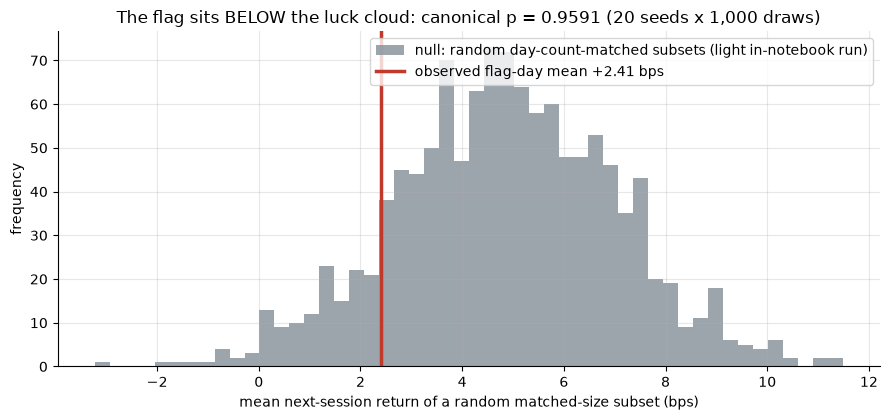

canonical placebo (results.md): mean +4.85 bps, sd 1.41, p = 0.9591


In [2]:
if HAVE_REAL:
    s = st.trend_day_stats(DF)
    print(f"flag {s['flag_bps']:+.2f} bps  (n={s['n_flag']})  vs  no-flag "
          f"{s['rest_bps']:+.2f} bps  (n={s['n_rest']})")
    print(f"Welch t = {s['welch_t']:+.2f}   NW(5) t = {s['nw_t']:+.2f}   "
          f"hit {s['hit_up']}/{s['n_flag']} = {s['hit_rate']*100:.1f}%  "
          f"Wilson [{s['hit_lo']*100:.1f}%, {s['hit_hi']*100:.1f}%]")
    pl = st.placebo_pvalue(DF, n_draws_per_seed=300, n_seeds=4)
    obs = pl['obs'] * 1e4
    rng = np.random.default_rng(678)
    draws = rng.choice(DF['fwd_ret'].dropna().values, size=(1200, s['n_flag'])).mean(axis=1) * 1e4
else:
    obs = R['placebo_obs']
    rng = np.random.default_rng(678)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 1200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random day-count-matched subsets (light in-notebook run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed flag-day mean {obs:+.2f} bps')
ax.set_xlabel('mean next-session return of a random matched-size subset (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"The flag sits BELOW the luck cloud: canonical p = {R['placebo_p']:.4f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.2f} bps, "
      f"sd {R['placebo_sd']:.2f}, p = {R['placebo_p']:.4f}")

> 💡 In plain words: the observed **+2.41 bps** sits *below* the null's center (+4.85 ± 1.41 bps); **p = 0.9591** means a random day-count-matched subset does at least as well as the flag **96% of the time**. H₁ is not merely unsupported on SPY alone — the flag actively selects a below-average subset.

### 4b · Cross-instrument pooling — one lucky tape can't carry this

The same split on SPY, QQQ, IWM, DIA and GLD, per-ticker and pooled.

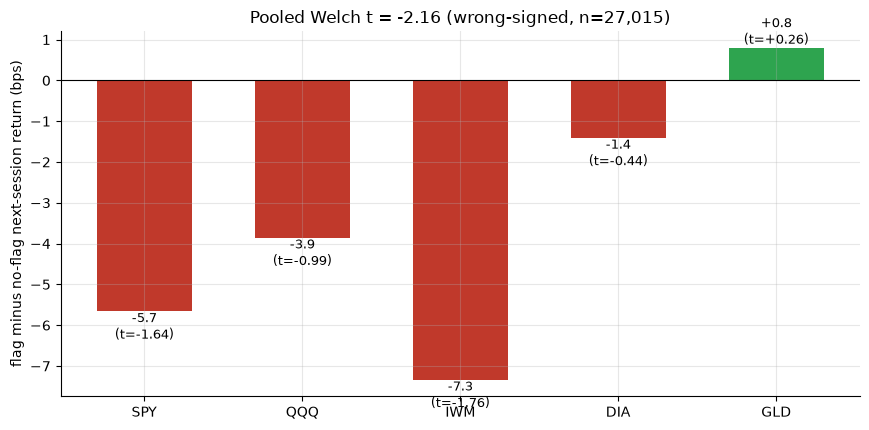

pooled: flag +3.47 bps vs rest +6.92 bps  t=-2.16


In [3]:
tickers = list(R['per_ticker'])
if HAVE_REAL:
    xi = st.cross_instrument_stats(BASKET)
    rows = [(t, xi['per_ticker'][t]['n_flag'], xi['per_ticker'][t]['flag_bps'],
             xi['per_ticker'][t]['rest_bps'], xi['per_ticker'][t]['gap_bps'],
             xi['per_ticker'][t]['welch_t'], xi['per_ticker'][t]['nw_t'],
             xi['per_ticker'][t]['hit_rate']*100) for t in tickers]
    pooled_t = xi['pooled']['welch_t']
    pooled_flag, pooled_rest = xi['pooled']['flag_bps'], xi['pooled']['rest_bps']
else:
    rows = [(t, *R['per_ticker'][t]) for t in tickers]
    pooled_t, pooled_flag, pooled_rest = R['pooled_t'], R['pooled_flag_bps'], R['pooled_rest_bps']
gaps = [r[4] for r in rows]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [RED if g < 0 else GREEN for g in gaps]
ax.bar(tickers, gaps, color=cols, width=.6)
for i,(t_,*rest) in enumerate(rows):
    ax.annotate(f'{rest[3]:+.1f}\n(t={rest[4]:+.2f})',(i,rest[3]),ha='center',
        va='top' if rest[3]<0 else 'bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('flag minus no-flag next-session return (bps)')
ax.set_title(f'Pooled Welch t = {pooled_t:+.2f} (wrong-signed, n=27,015)')
plt.tight_layout(); plt.show()
print(f'pooled: flag {pooled_flag:+.2f} bps vs rest {pooled_rest:+.2f} bps  t={pooled_t:+.2f}')

> 💡 In plain words: four of five markets show a negative gap; pooled (n = 27,015) the Welch *t* is **-2.16** — it *clears* the ±2 desk bar, in the direction that says "the flag picks worse days," not better ones. This is the strongest single number in the study: not "we found nothing," but "we found the opposite of the claim, and it's real."

### 4c · The book — gross, net, and the fair control

The RWI-high long timer (one-day lag, position 0/1, cost x NAV per leg on every position change) vs buy & hold *and* vs a block-shuffled random-entry control that preserves the timer's exposure and turnover profile while destroying the flag's real calendar placement.

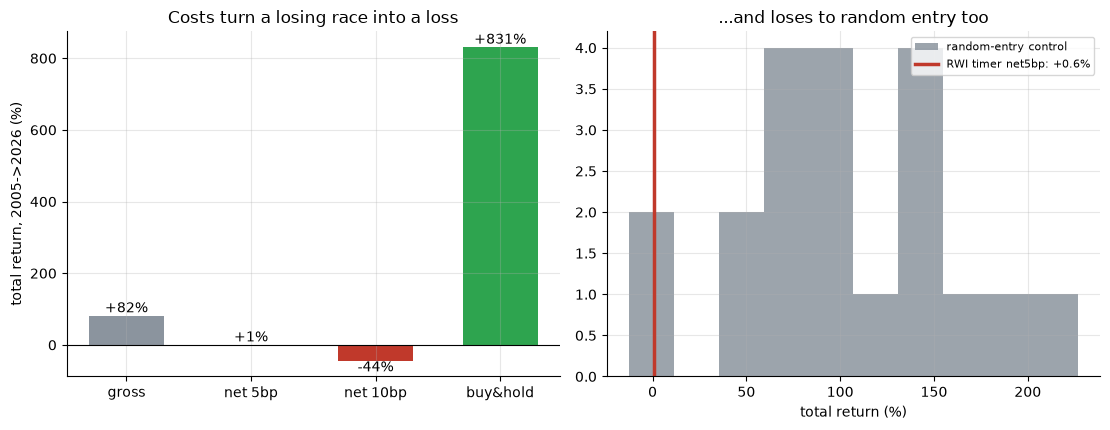

gross +81.8%  net5 +0.6%  net10 -44.4%  buy&hold +831.3%
random-entry control: mean +98.6%  vs timer +0.6%


In [4]:
if HAVE_REAL:
    rows_bt = [st.backtest(DF, cost_bps=cb) for cb in (0.0, 5.0, 10.0)]
    g, n5, n10 = [r['total_return_pct'] for r in rows_bt]
    bh = rows_bt[0]['bh_total_return_pct']
    rc = st.random_control_backtest(DF, cost_bps=5.0, block_size=21, n_seeds=20)
    rc_draws = rc['draws_total_return_pct']
else:
    g, n5, n10, bh = R['gross_ret'], R['net5_ret'], R['net10_ret'], R['bh_ret']
    rng = np.random.default_rng(678)
    rc_draws = rng.normal(R['rc_mean_ret'], R['rc_sd_ret'], 20)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar(['gross','net 5bp','net 10bp','buy&hold'], [g, n5, n10, bh],
       color=[GREY, AMBER, RED, GREEN], width=.6)
for i,v in enumerate([g, n5, n10, bh]): a1.annotate(f'{v:+.0f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('total return, 2005->2026 (%)')
a1.set_title('Costs turn a losing race into a loss')
a2.hist(rc_draws, bins=10, color=GREY, alpha=.85, label='random-entry control')
a2.axvline(n5, c=RED, lw=2.5, label=f'RWI timer net5bp: {n5:+.1f}%')
a2.set_xlabel('total return (%)'); a2.set_title('...and loses to random entry too')
a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%  net5 {n5:+.1f}%  net10 {n10:+.1f}%  buy&hold {bh:+.1f}%')
print(f'random-entry control: mean {rc_draws.mean():+.1f}%  vs timer {n5:+.1f}%')

> 💡 In plain words: even **before** costs the timer captures only **82%** against buy & hold's **831%** — being long only **57%** of the time already forgoes most of the compounding, and **1,184 position changes** over 21.5 years bleed real cost. At 10 bps one-way it's **-44.4%** — a loss. And the block-shuffled control, matched for the *same* exposure and turnover, beats the real rule in **90%** of 20 draws by total return and **95%** by Sharpe. **H₃ rejected; Tradability = MIRAGE, third axis = BUSTED.**

### 4d · Faithful-engine & power control — we know the truth here

Two-regime (trend/chop) Markov world, both regimes sharing the same daily shock scale, TUNABLE planted trend-persistence edge. The null (edge = 0) is checked over **20 seeds** — never a single stream.

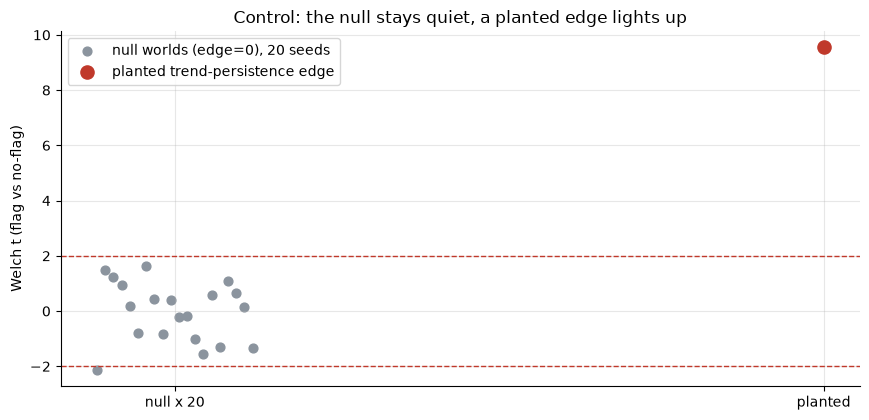

null: mean t = -0.03 (sd 1.09), |t|>=2 in 1/20 seeds  |  planted t = +9.54


In [5]:
null_ts = []
for s_ in range(20):
    ohlc = data.synthetic_world(edge=0.0, seed=678 + s_)
    null_ts.append(st.synthetic_detect(ohlc)['welch_t'])
null_ts = np.asarray(null_ts)
ohlc = data.synthetic_world(edge=0.006, seed=678)
planted = st.synthetic_detect(ohlc)
planted_t = planted['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted trend-persistence edge')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (flag vs no-flag)')
ax.set_title('Control: the null stays quiet, a planted edge lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.03 (sd 1.09) and crosses the ±2 bar in only 1/20 seeds — right at the ~5% nominal false-positive rate, not biased. A generously sized planted trend-persistence edge reads t = 9.54 with a 65% hit rate. The machinery works and can find a real edge when one exists — the real-tape null (and wrong-signed pooled result) is the genuine article, not a broken detector.

## 5 · The verdict

- **Signal `NONE`** — RWI-high > 1 fires on 57% of SPY sessions and does not predict a better next-session return: SPY alone runs backwards at *t* = -1.64, and pooled across five instruments the wrong-signed gap clears the bar (Welch *t* = -2.16). A matched-count random-day placebo beats the flag's own mean 96% of the time.
- **Tradability `MIRAGE`** — the long timer returns +81.8% gross vs buy & hold's +831.3%, and turns net-negative (-44.4%) at 10 bps one-way costs.
- **"Beats a coin?" `BUSTED`** — a block-shuffled, exposure-matched random-entry control beats the real timer in 90% of draws by total return and 95% by Sharpe. The rule loses to picking days at random.

## 6 · Going further

- **The general lesson is about the whole trend-strength-gate family.** ADX, the Vertical-Horizontal-Filter, a rolling Hurst exponent and now the RWI all measure *something real* about recent price behavior — and none of them forecast what happens next. "This move doesn't look random" and "this move will continue" are different claims; the indicators only ever test the first.
- **A genuinely different next test:** does the RWI carry information as a *volatility-regime* / position-sizing input (larger realized-vs-ATR displacement -> smaller size, expecting reversion) rather than a directional trigger? The pooled wrong-signed result here is a hint in that direction, not a tested claim.
- **Dedup map:** [108-adx-filter](../../108-adx-filter/) (Wilder's ADX gate), [484-vertical-horizontal-filter](../../484-vertical-horizontal-filter/) (White's VHF gate), [397-hurst-regime](../../397-hurst-regime/) (rolling R/S Hurst switch) — four formulas, the same "is this a real trend" question, the same answer.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*